In [43]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# 1. Business / Problem Understanding

> The Objective of this project is to identify patients at high risk of heart disease using routinely collected clinical information. Since missing patient with heart disease is costly, recall and F1-Score will be emphasized over Accuracy

# 2. Data Understanding

> After defining the problem and the project objectives, the next critical step is to develop a comprehensive understanding of the available data, evaluate its quality, and ensure the data used for model training are of high quality, representative, and free from bias as possible.

In [44]:
df = pd.read_csv('/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [45]:
df.describe(include='all')

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


The original label consists of four labels; however, this project focus solely on predicting the presence or absence of heart disease rather than its severity. Accordingly, we need to transform the label from the original 0,1,2,3,4 into binary values 0 and 1, representing negative and positive cases of heart disease, respectively

In [46]:
df.rename(columns={'num' : 'target'}, inplace=True) #Rename the label from num to target for easier interpretation

As observed from `df.describe()` output above, the `chol` and `trestbps` feature contains a value of 0, which falls outside the physiologically normal range, as human cholesterol and resting blood sugar levels cannot be that low. Same with `oldpeak` which is representing ST depression induced by exercise relative to rest, plausible range for this features is between zero to about six and negative value is representing ST elevation rather than ST depression. Since from the original documentation the variable is specifically defined as ST depression, negative values are generally considered incosistent with the feature definition. This is presumed to be attributable to measurement error; therefore, we convert these instances to missing data.

In [47]:
df['chol'] = df['chol'].apply(lambda x: np.nan if x == 0 else x)
df['trestbps'] = df['trestbps'].apply(lambda x: np.nan if x == 0 else x)
df['oldpeak'] = df['oldpeak'].apply(lambda x: np.nan if x < 0 else x)

In [48]:
# Enquire the percentage of missing data in each column
pd.DataFrame(df.isna().mean().sort_values(ascending=False) * 100).rename(columns={0: 'Percentage'}) 

,Percentage
ca,66.413043
thal,52.826087
slope,33.586957
chol,21.956522
fbs,9.782609
oldpeak,8.043478
trestbps,6.521739
thalch,5.978261
exang,5.978261
restecg,0.217391


As indicated in the output above, ten columns contain missing values, four of which exhibit missingness exceeding twenty percent of their total entries. Prior to determining whether to drop or impute the missing data, it is necessary to assess whether the missingness is random and whether it correlates with the predicition outcome.

In [49]:
# We want examine the data distribution including missing values using histograms and assess their correlation with the target

df_with_missing = df.copy()
for col in df_with_missing.columns: #For visualization purpose, the missing values temporarily encoded as -10
    impute = '-10' if df_with_missing[col].dtype == 'object' else -10 
    df_with_missing[col] = df_with_missing[col].fillna(impute)

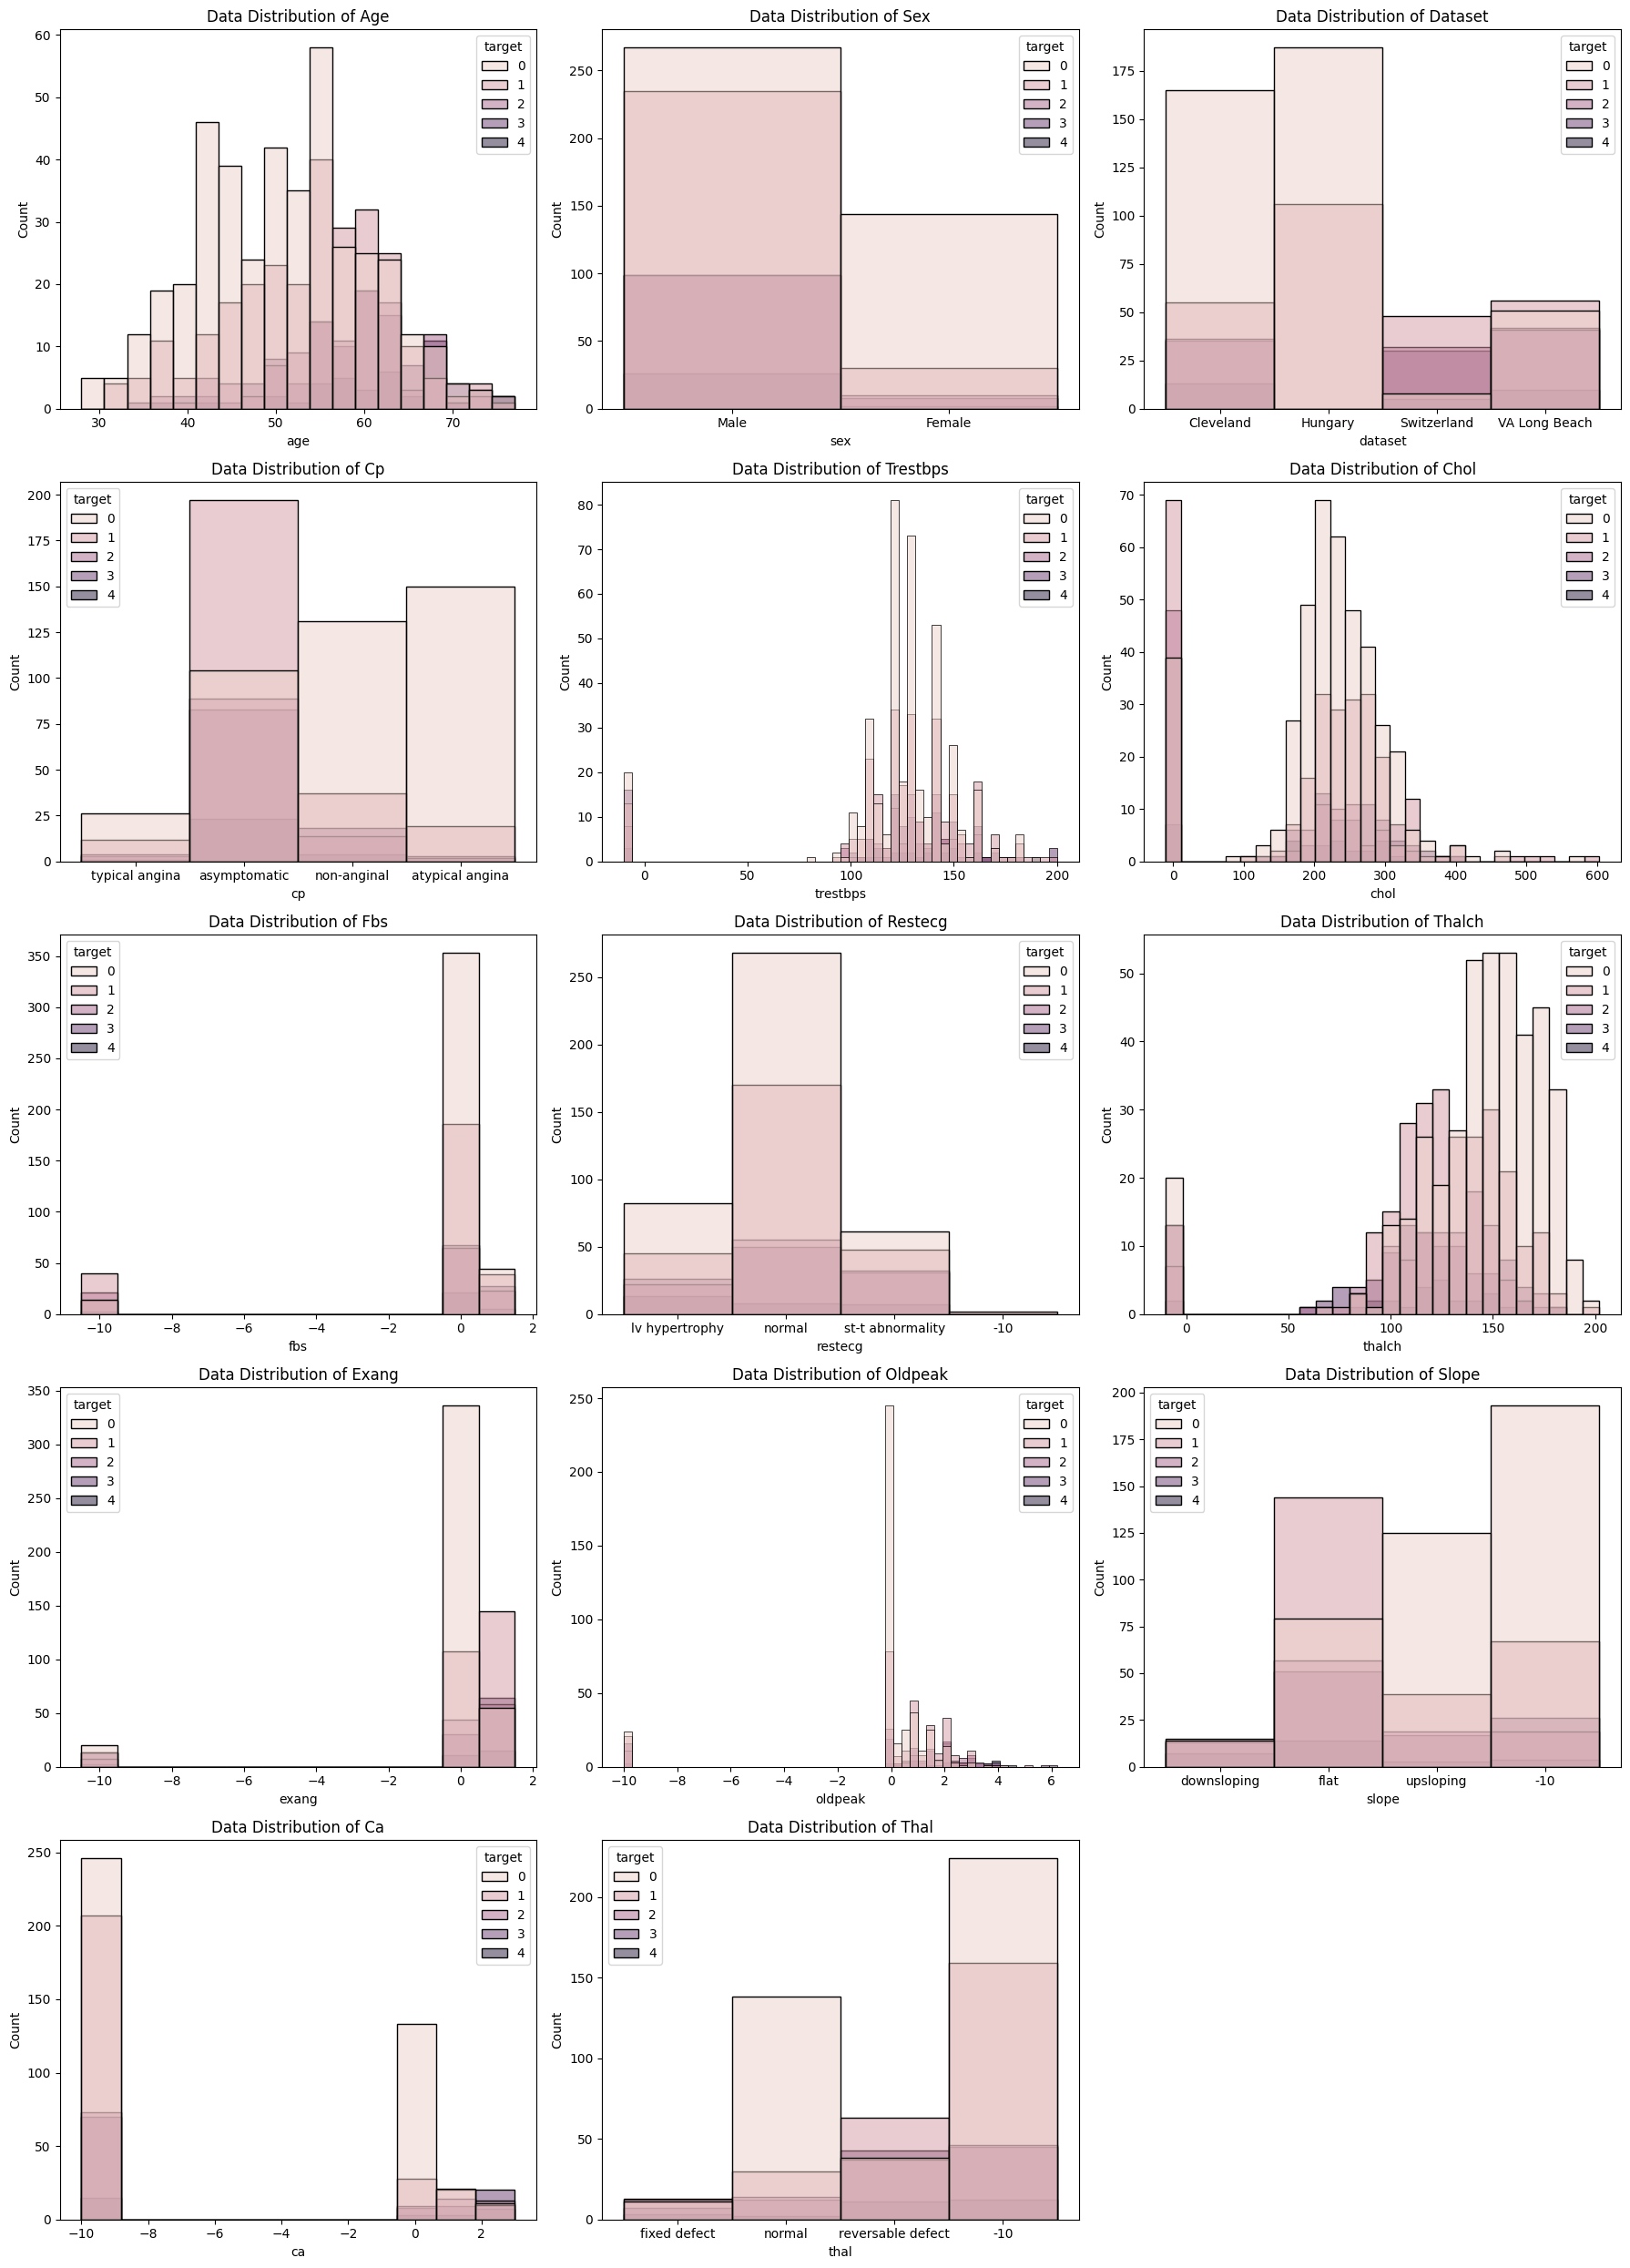

In [50]:
columns = ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
           'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal',]

def create_plot(plot, data, columns, hue=None, title=None):
    rows = (len(columns) + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))

    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        plot(data=data, x=col, ax=ax, hue=hue)
        ax.set_title(f'{title} {col.title()}')

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


create_plot(sns.histplot, df_with_missing, columns, hue='target', title='Data Distribution of')

From the chart above we can see the distribution of each features and we can see that missing data in all features is containing higher percentage of positive label which might indicating that missing value is associated with heart disease in patient. One possible explanation is that patients with more severe clinical presentations underwent incomplete testing; however, this hypothesis cannot be verified from the available data and would require knowledge of the data collection process, we need to investigate further about the plausible cause of the missing value to create best imputation strategy

In [51]:
df['has_missing'] = df.isna().any(axis=1)
pd.crosstab(df['has_missing'], df['target'], normalize='index')

target,0,1,2,3,4
has_missing,,,,,
False,0.535117,0.187291,0.117057,0.117057,0.043478
True,0.404187,0.336554,0.119163,0.115942,0.024155


In [52]:
df['target'] = (df['target'] > 0).astype(int) #Transform the label binary classes
pd.crosstab(df['has_missing'], df['target'], normalize='index')

target,0,1
has_missing,,
False,0.535117,0.464883
True,0.404187,0.595813


Based on the output above, missing values appear to be correlated with the occurence of heart disease, though less so with its severity. Therefore for simplicity and given that the objective of this project is to predict only the presence or absence of heart disease rather than its degree of severity, we transformed the label into binary values 0 for negative case and 1 for positive case.

In [53]:
pd.crosstab(df['dataset'], df['has_missing'], normalize='index')

has_missing,False,True
dataset,,
Cleveland,0.976974,0.023026
Hungary,0.003413,0.996587
Switzerland,0.000000,1.000000
VA Long Beach,0.005000,0.995000


For all three dataset except Cleveland, more than 99% of the values are missing, which provide insight about the cause of missing value that might associated with dataset source

In [54]:
pd.crosstab([df['dataset'], df['has_missing']], df['target'], normalize='all', margins=True)

target                            0         1       All
dataset       has_missing                              
Cleveland     False        0.173913  0.148913  0.322826
              True         0.005435  0.002174  0.007609
Hungary       False        0.000000  0.001087  0.001087
              True         0.203261  0.114130  0.317391
Switzerland   True         0.008696  0.125000  0.133696
VA Long Beach False        0.000000  0.001087  0.001087
              True         0.055435  0.160870  0.216304
All                        0.446739  0.553261  1.000000

In [55]:
pd.crosstab(df['dataset'], df['has_missing'], normalize='index')

has_missing,False,True
dataset,,
Cleveland,0.976974,0.023026
Hungary,0.003413,0.996587
Switzerland,0.000000,1.000000
VA Long Beach,0.005000,0.995000


Based on the output above, dataset from `Switzerland` and `VA Long Beach` have more than 99% of their data missing, at the same time patient in those dataset have significantly higher rate of heart disease but if we look at `Cleveland` and `Hungary` dataset its appear that missing value occur more in the absence of heart disease, therefore we can assume that missing values is not strongly correlated with the presence of heart disease, but rather are more associated with source of the dataset.

In [56]:
pd.crosstab(df['dataset'], df['sex'], normalize='all', margins=True)

sex,Female,Male,All
dataset,,,
Cleveland,0.105435,0.225000,0.330435
Hungary,0.088043,0.230435,0.318478
Switzerland,0.010870,0.122826,0.133696
VA Long Beach,0.006522,0.210870,0.217391
All,0.210870,0.789130,1.000000


In [57]:
pd.crosstab([df['dataset'], df['sex']], df['has_missing'], normalize='all')

has_missing              False     True 
dataset       sex                       
Cleveland     Female  0.104348  0.001087
              Male    0.218478  0.006522
Hungary       Female  0.000000  0.088043
              Male    0.001087  0.229348
Switzerland   Female  0.000000  0.010870
              Male    0.000000  0.122826
VA Long Beach Female  0.000000  0.006522
              Male    0.001087  0.209783

In [58]:
df.groupby('has_missing')['age'].mean()

has_missing
False    54.521739
True     53.024155
Name: age, dtype: float64

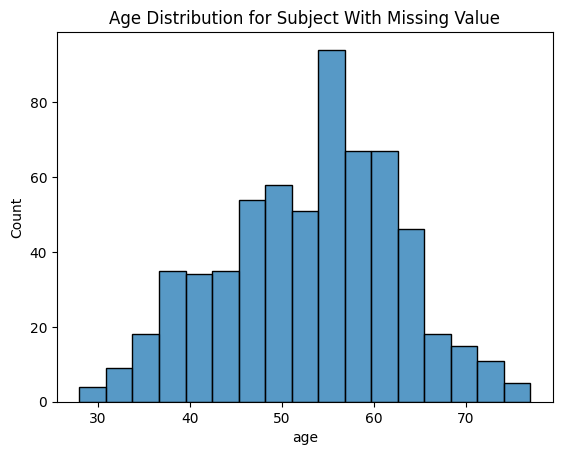

In [59]:
sns.histplot(df[df['has_missing']==True]['age'])
plt.title('Age Distribution for Subject With Missing Value')
plt.show()

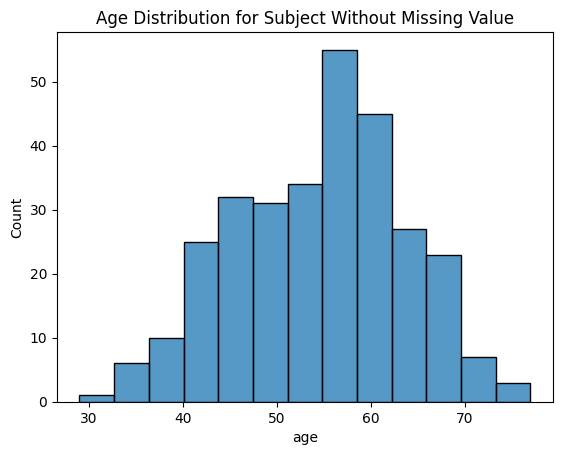

In [60]:
sns.histplot(df[df['has_missing']==False]['age'])
plt.title('Age Distribution for Subject Without Missing Value')
plt.show()

>Based on the output above, all datasets except `Cleveland` exhibit a substantially higher frequency of missing value among `males` than `females`. However, this pattern is likely attributable to the greater representation of male subjects within these datasets rather than a direct association between missingness and sex. Additionally, missingness does not appear to be related to `age`, as observation with missing and non-missing values show similar distributions and means value. Taken together, these findings suggest that missingness is primarily associated with the datasets source, supporting the plausibility of the `Missing At Random (MAR)` assumption. However, because the underlying data collection process is unknown, the possibility of `Missing Not At Random (MNAR)` mechanism cannot be excluded.

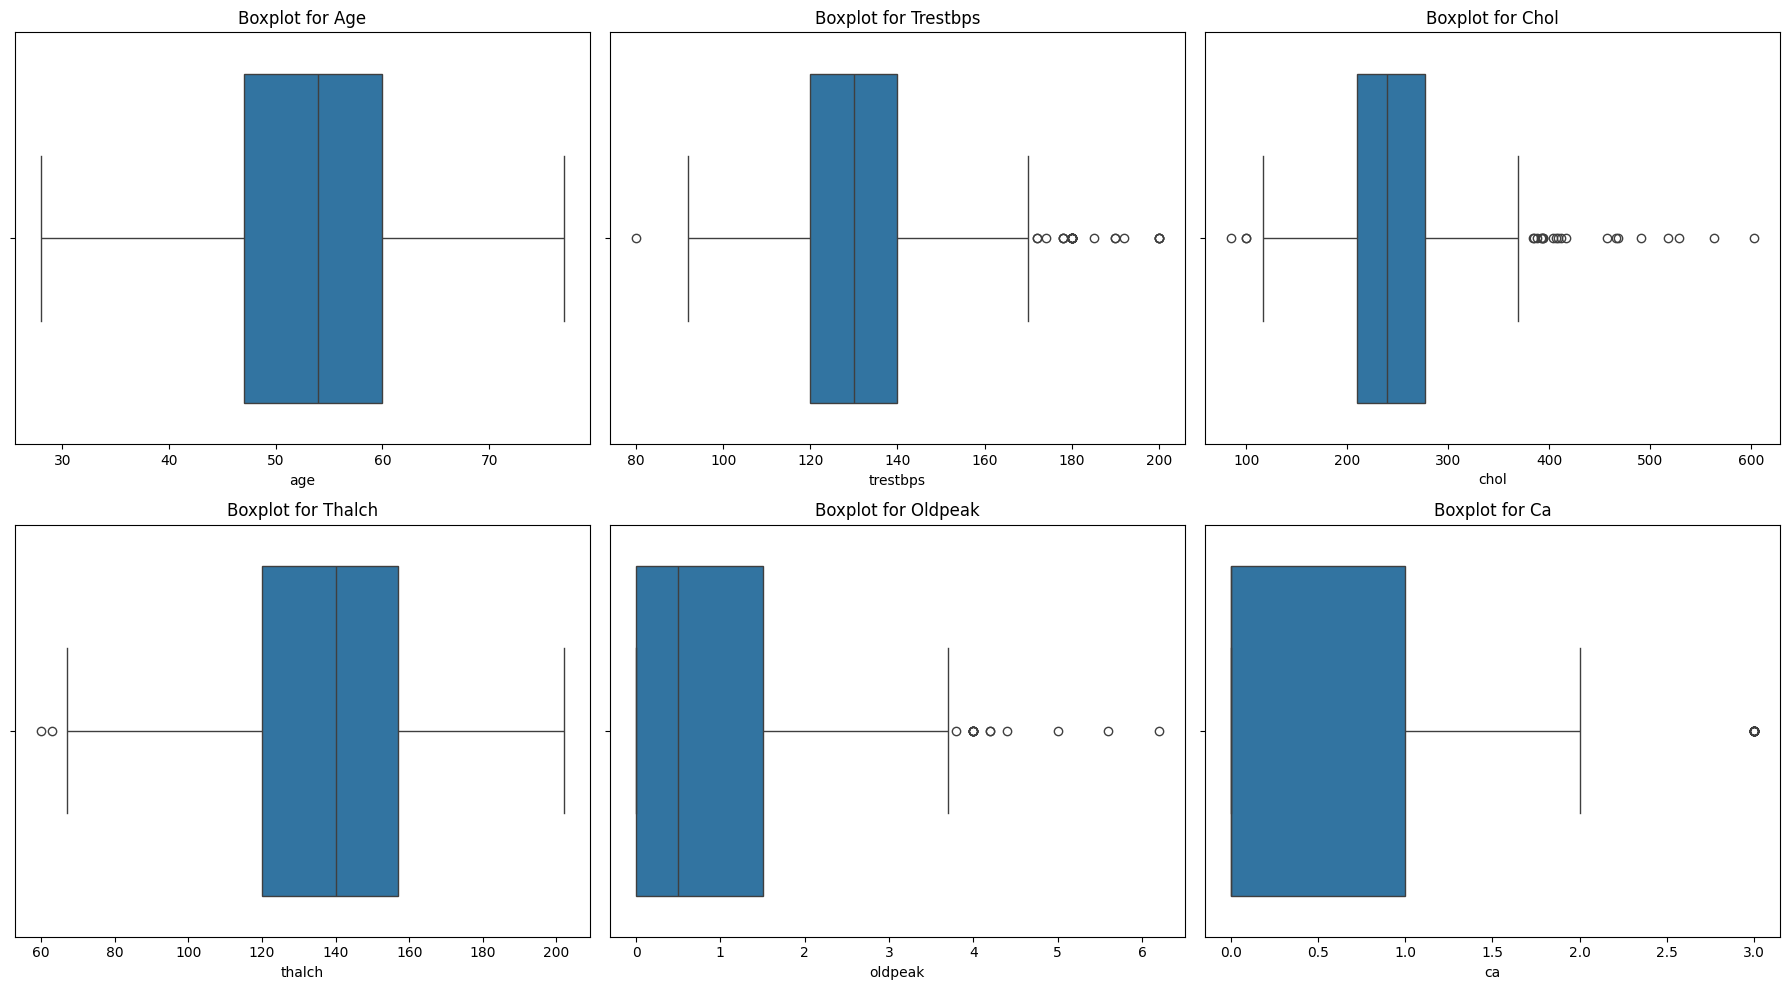

In [61]:
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
cat_features = ['sex', 'fbs', 'exang', 'slope', 'thal', 'restecg', 'cp']


create_plot(sns.boxplot, df, numeric_features, title='Boxplot for')

Based on the boxplot above we can observe the distributions for every numeric features, given the boxplot it appears that every features except for `age` contain outliers. We need to investigate further about the features to provide insight which lead to better handling strategy for the outliers. For resting blood pressure which is `trestbps` range for this data is fallen between eighty to two hundred mmHg. Altough the boxplot shows there is some outliers, all outliers still fallen in possible pysiologically range for resting blood preassure, dropping the outliers might remove useful signal for the model. Same with Cholesterol `chol`, maximum heart rate `thalch`, and number of major vessel `ca` outliers in these features is still fallen in possible range, therefore dropping the outliers wont be necessary.

# 3. Data Cleaning

In [62]:
df['n_missing'] = df.isna().sum(axis=1)
df['n_missing'].value_counts().sort_index()

n_missing
0    299
1     26
2    211
3    228
4     89
5     11
6      2
7     43
8     11
Name: count, dtype: int64

Some rows contain heavily missing data, this can lead to quality issue because the rows with majority of its features is missing can't provide reliable information for the model to learn, furthermore the model can learn if missing data is strongly correlated with target and heavily influenced the prediction if rows with heavily missing data have imbalanced classes. 

In [66]:
df.columns

AttributeError: 'DataFrame' object has no attribute 'columnsd'

In [ ]:
# Dropping arbitrarily rows with heavily missing values
df = df.dropna(thresh=12)

# 4. Feature Engineering

In [ ]:
X = df[['age', 'sex', 'cp', 'trestbps', 'chol', 
        'fbs', 'restecg', 'thalch', 'exang', 
        'oldpeak', 'slope', 'ca', 'thal']]

y = df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    stratify=y,
    random_state=0
) 

In [ ]:
# Removing anomaly 

class ClinicalCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X.loc[X['chol'] <= 0, 'chol'] = np.nan
        X.loc[X['oldpeak'] < 0, 'oldpeak'] = np.nan
        return X
    
# Numeric Pipeline

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

# Categorical Pipeline

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Transformation

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, cat_features)
])

# 5. Model Development

In [ ]:
model = Pipeline([
    ('clinical_cleaner', ClinicalCleaner()),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state = 42))
])


model.fit(X_train, y_train)
y_pred = model.predict(X_val)
accuracy_score(y_val, y_pred)

8275

In [ ]:
print(classification_report(y_val, y_pred))

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

print(scores)
print(scores.mean())
print(scores.var())

###### 

In [ ]:
## Create a list of algorithm to compare ##
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM' : SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGB': XGBClassifier(random_state=42)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Create a list of metrics ##
scoring = [
    'accuracy', 
    'precision',
    'recall', 
    'f1',
    'roc_auc'
]

In [ ]:
result = []

for name, model in models.items():

    pipeline = Pipeline([
        ('clinical_cleaner', ClinicalCleaner()),
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    result.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean()
    })

In [ ]:
comparison = pd.DataFrame(result)

comparison.sort_values(
    by="F1",
    ascending=False,
    inplace=True
)

comparison

In [ ]:
pipeline = Pipeline([
        ('clinical_cleaner', ClinicalCleaner()),
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=5000))
    ])


param_grid = [
    
    # liblinear
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    },

    # lbfgs
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    },

    # saga
    {
        "classifier__solver": ["saga"],
        "classifier__penalty": ["elasticnet"],
        "classifier__l1_ratio": [0.2, 0.5, 0.8],
        "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    }
]

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

In [ ]:
print(grid.best_params_)
print(grid.best_score_)
print(grid.best_estimator_)

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_prob))

In [ ]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importances = (best_model.named_steps['classifier'].coef_[0])
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
})

importance_df = importance_df.sort_values('Importance', ascending=False)

print(importance_df)

As we can see from the output above that the model gives high importance value for missing indicators, while missing indicators might not directly correlated with the occurrence of heart disease, they are probably contain valuable information about the occurrence of heart disease. However this model might only reliable to predict future data that has similar workflow and data collection system which missing data will has similar information, thus, using this model to predict heart disease outside those hospitals that are included in training dataset might introduce potential bias prediction. The scope of the model can be expanded by choosing features that are not influenced by dataset source such as the information given by missing data with trade-offs lower metrics evaluation. 

In [ ]:
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot();

In [ ]:
result = X_val.copy()
result['Actual'] = y_val.values
result['Predicted'] = y_pred
result['Predicted_prob'] = y_prob

missclassified = result[result['Actual'] != result['Predicted']].sort_values(by='Predicted_prob').reset_index().drop(columns='index')
missclassified

In [ ]:
fn = missclassified[missclassified['Predicted'] == 0]
fp = missclassified[missclassified['Predicted'] == 1]

print(fn.isna().sum())
print(f'Total Missing Value: {fn.isna().sum().sum()}')
print(f'Missing value per row: {fn.isna().sum().sum() / len(fn.index)}')
print('')
print(fp.isna().sum())
print(f'Total Missing Value: {fp.isna().sum().sum()}')
print(f'Missing value per row: {fp.isna().sum().sum() / len(fp.index)}')

In [ ]:
y_prob